##Dataset Acquisition

In [ ]:
from google.colab import files
print("upload kaggle.json")
uploaded = files.upload()

upload kaggle.json


Saving kaggle (1).json to kaggle (1).json


In [1]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:46<00:00, 119MB/s]



In [2]:
!unzip -q skin-cancer-mnist-ham10000.zip -d ham10000

##Dataset Structure Inspection

In [53]:
import os

dataset_path = "/content/ham10000"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print(f"{len(files)} files")

/content/ham10000
5 files
/content/ham10000/HAM10000_images_part_2
5015 files
/content/ham10000/HAM10000_images_part_1
5000 files
/content/ham10000/ham10000_images_part_1
5000 files
/content/ham10000/ham10000_images_part_2
5015 files


In [54]:
import glob

glob.glob("/content/ham10000/*")

['/content/ham10000/hmnist_28_28_RGB.csv',
 '/content/ham10000/HAM10000_images_part_2',
 '/content/ham10000/HAM10000_images_part_1',
 '/content/ham10000/hmnist_8_8_L.csv',
 '/content/ham10000/hmnist_28_28_L.csv',
 '/content/ham10000/hmnist_8_8_RGB.csv',
 '/content/ham10000/HAM10000_metadata.csv',
 '/content/ham10000/ham10000_images_part_1',
 '/content/ham10000/ham10000_images_part_2']

In [55]:
import pandas as pd

metadata = pd.read_csv("/content/ham10000/HAM10000_metadata.csv")

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [56]:
metadata.shape

(10015, 7)

In [57]:
metadata.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

In [58]:
metadata['dx'].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [59]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_dir1 = "/content/ham10000/HAM10000_images_part_1"
image_dir2 = "/content/ham10000/HAM10000_images_part_2"

metadata["path"] = metadata["image_id"].apply(
    lambda x: os.path.join(image_dir1, x + ".jpg")
    if os.path.exists(os.path.join(image_dir1, x + ".jpg"))
    else os.path.join(image_dir2, x + ".jpg")
)

metadata[["image_id", "dx", "path"]].head()

,image_id,dx,path
0,ISIC_0027419,bkl,/content/ham10000/HAM10000_images_part_1/ISIC_...
1,ISIC_0025030,bkl,/content/ham10000/HAM10000_images_part_1/ISIC_...
2,ISIC_0026769,bkl,/content/ham10000/HAM10000_images_part_1/ISIC_...
3,ISIC_0025661,bkl,/content/ham10000/HAM10000_images_part_1/ISIC_...
4,ISIC_0031633,bkl,/content/ham10000/HAM10000_images_part_2/ISIC_...


##Visualizing Samples from Each Lesion Class

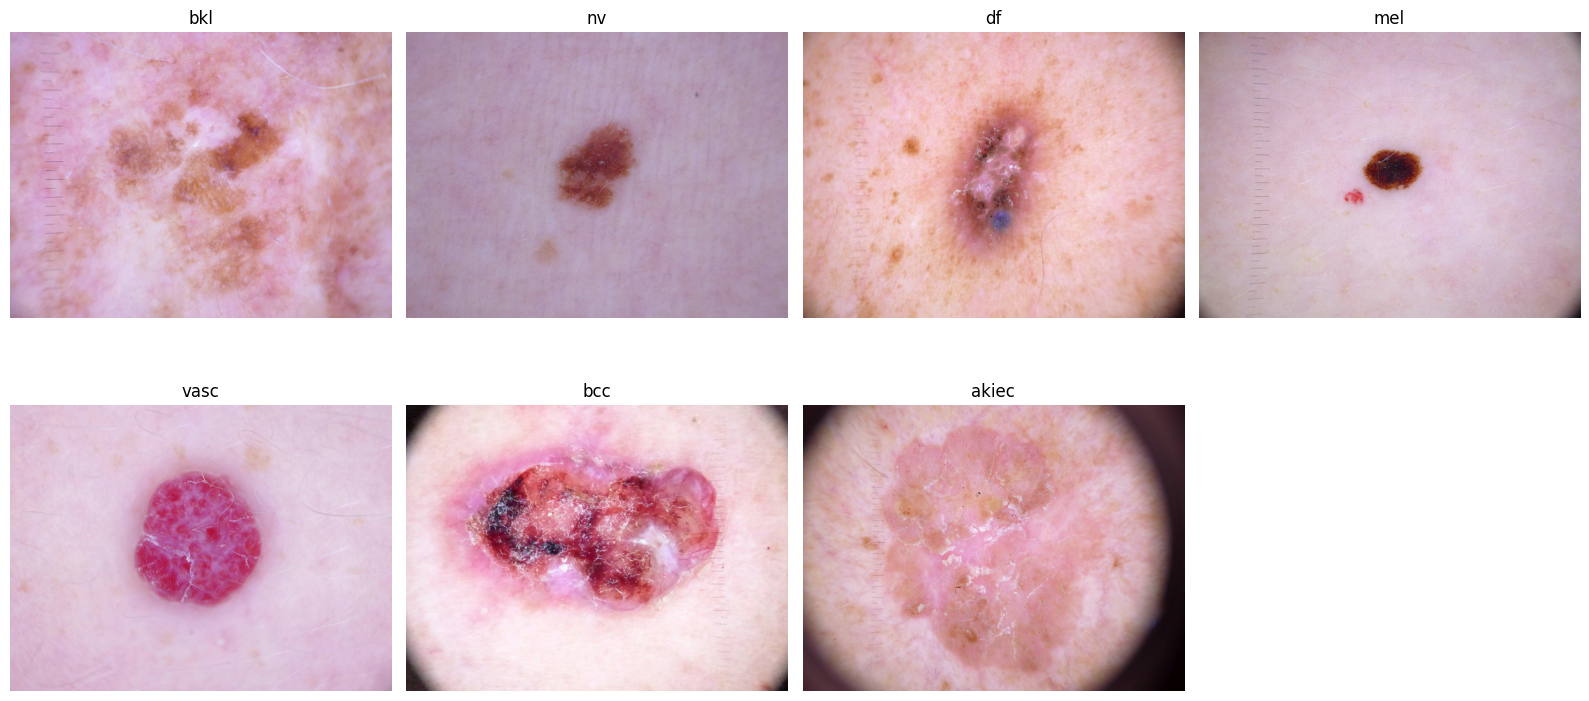

In [60]:
classes = metadata["dx"].unique()

plt.figure(figsize=(16,8))

for i, cls in enumerate(classes):
    sample = metadata[metadata["dx"] == cls].iloc[0]

    img = Image.open(sample["path"])

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

##Stratified Train/Validation split

In [61]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    metadata,
    test_size=0.2,
    stratify=metadata["dx"],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))

Training: 8012
Validation: 2003


##Encoding Diagnostic Labels

In [62]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

train_df["label"] = encoder.fit_transform(train_df["dx"])
val_df["label"] = encoder.transform(val_df["dx"])

print(encoder.classes_)

['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


##Image Preprocessing & Data Augmentation

In [63]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

##Custom Skin Lesion Dataset

In [64]:
from torch.utils.data import Dataset
from PIL import Image

class SkinDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(row["path"]).convert("RGB")

        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

##DataLoaders

In [65]:
from torch.utils.data import DataLoader

train_dataset = SkinDataset(train_df, train_transform)
val_dataset = SkinDataset(val_df, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [66]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [67]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


##Loading a Pretrained ResNet50 Model

In [69]:
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

##Freezing the Pretrained Backbone

In [70]:
for param in model.parameters():
    param.requires_grad = False

##Adapting ResNet50 for Skin Lesion Classification

In [71]:
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 7)
)

In [72]:
model = model.to(device)

##Handling Class Imbalance with Class Weights

In [73]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

##Loss Function and Optimizer

In [74]:
criterion = nn.CrossEntropyLoss(weight=class_weights)



optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

In [75]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [76]:
!pip install -q tqdm

In [77]:
from tqdm import tqdm
import copy

##EarlyStopping

In [78]:
class EarlyStopping:

    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = float("inf")
        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0

        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

##Learning Rate Scheduling

In [79]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

##Training Loop for One Epoch

In [80]:
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

##Validation Loop

In [81]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

##Model Training

In [82]:
num_epochs = 15

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_model = copy.deepcopy(model.state_dict())

best_acc = 0

early_stopping = EarlyStopping(patience=5)

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    if val_acc > best_acc:

        best_acc = val_acc

        best_model = copy.deepcopy(model.state_dict())

        torch.save(best_model, "best_resnet50_skin.pth")

        print("Best model saved!")

    early_stopping(val_loss)

    if early_stopping.early_stop:

        print("Early stopping!")

        break


Epoch 1/15


100%|██████████| 63/63 [00:22<00:00,  2.79it/s]


Train Loss : 1.5523
Train Acc  : 0.5366
Val Loss   : 1.2944
Val Acc    : 0.6296
Best model saved!

Epoch 2/15


100%|██████████| 63/63 [00:22<00:00,  2.77it/s]


Train Loss : 1.2538
Train Acc  : 0.5852
Val Loss   : 1.1252
Val Acc    : 0.6635
Best model saved!

Epoch 3/15


...

Train Loss : 0.8252
Train Acc  : 0.6927
Val Loss   : 0.8813
Val Acc    : 0.7079

Epoch 14/15


100%|██████████| 63/63 [00:22<00:00,  2.77it/s]


Train Loss : 0.8169
Train Acc  : 0.6821
Val Loss   : 0.8954
Val Acc    : 0.7339

Epoch 15/15


100%|██████████| 63/63 [00:22<00:00,  2.77it/s]

Train Loss : 0.7992
Train Acc  : 0.6882
Val Loss   : 0.8715
Val Acc    : 0.7154


In [83]:
model.load_state_dict(torch.load("best_resnet50_skin.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

##Training and Validation Loss Curve

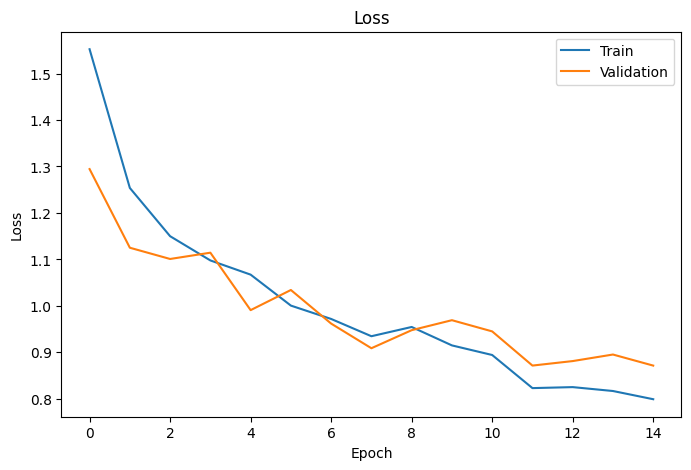

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

##Training and Validation Accuracy Curve

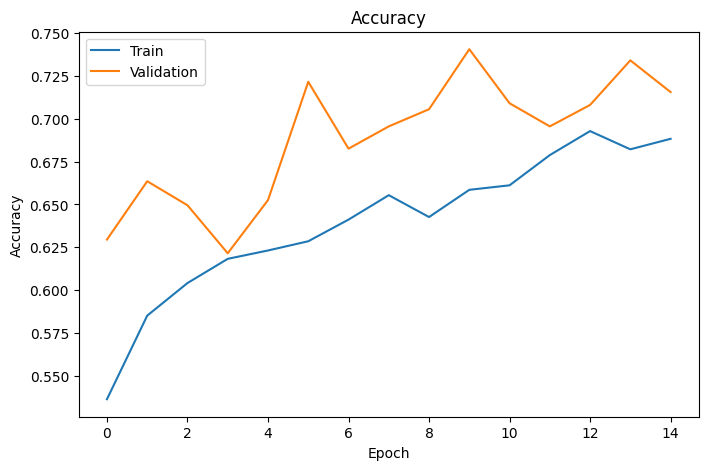

In [85]:
plt.figure(figsize=(8,5))
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

##Confusion Matrix

In [86]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [ ]:
cm = confusion_matrix(y_true, y_pred)

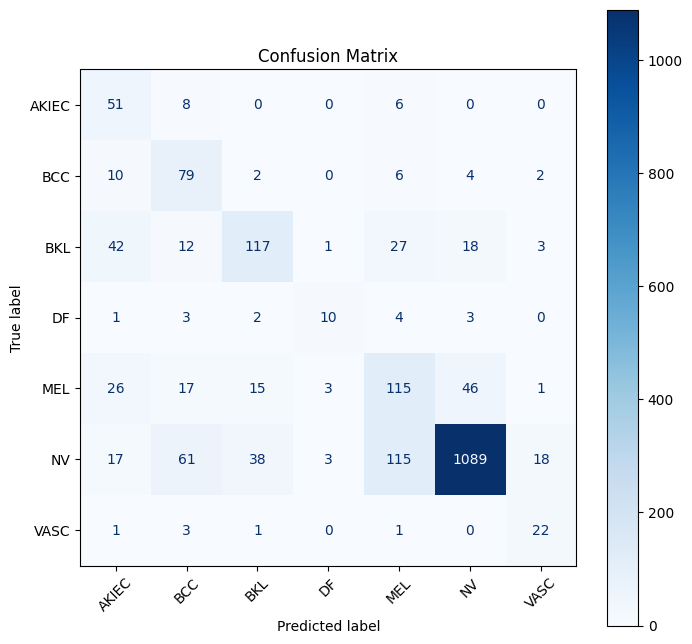

In [94]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

class_names = [
    "AKIEC",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "VASC"
]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

plt.title("Confusion Matrix")
plt.show()

##Classification Report

In [95]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

       AKIEC       0.34      0.78      0.48        65
         BCC       0.43      0.77      0.55       103
         BKL       0.67      0.53      0.59       220
          DF       0.59      0.43      0.50        23
         MEL       0.42      0.52      0.46       223
          NV       0.94      0.81      0.87      1341
        VASC       0.48      0.79      0.59        28

    accuracy                           0.74      2003
   macro avg       0.55      0.66      0.58      2003
weighted avg       0.80      0.74      0.76      2003



##Grad-CAM

In [96]:
!pip install -q grad-cam

In [98]:
def generate_gradcam(model, dataset, index, cam):
    model.eval()

    image, true_label = dataset[index]

    input_tensor = image.unsqueeze(0).to(device)


    with torch.no_grad():
        output = model(input_tensor)

        probabilities = torch.softmax(output, dim=1)

        predicted_class = output.argmax(dim=1).item()
        confidence = probabilities[0, predicted_class].item()


    targets = [
        ClassifierOutputTarget(predicted_class)
    ]


    rgb_img = image.permute(1, 2, 0).cpu().numpy()

    rgb_img = (rgb_img - rgb_img.min()) / (
        rgb_img.max() - rgb_img.min() + 1e-8
    )


    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]


    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    return (
        image,
        true_label,
        predicted_class,
        confidence,
        grayscale_cam,
        visualization
    )


In [101]:
for name, param in model.named_parameters():
    if "layer4" in name:
        print(name, param.requires_grad)

layer4.0.conv1.weight False
layer4.0.bn1.weight False
layer4.0.bn1.bias False
layer4.0.conv2.weight False
layer4.0.bn2.weight False
layer4.0.bn2.bias False
layer4.0.conv3.weight False
layer4.0.bn3.weight False
layer4.0.bn3.bias False
layer4.0.downsample.0.weight False
layer4.0.downsample.1.weight False
layer4.0.downsample.1.bias False
layer4.1.conv1.weight False
layer4.1.bn1.weight False
layer4.1.bn1.bias False
layer4.1.conv2.weight False
layer4.1.bn2.weight False
layer4.1.bn2.bias False
layer4.1.conv3.weight False
layer4.1.bn3.weight False
layer4.1.bn3.bias False
layer4.2.conv1.weight False
layer4.2.bn1.weight False
layer4.2.bn1.bias False
layer4.2.conv2.weight False
layer4.2.bn2.weight False
layer4.2.bn2.bias False
layer4.2.conv3.weight False
layer4.2.bn3.weight False
layer4.2.bn3.bias False


In [102]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [103]:
for name, param in model.named_parameters():
    if "layer4" in name:
        print(name, param.requires_grad)

layer4.0.conv1.weight True
layer4.0.bn1.weight True
layer4.0.bn1.bias True
layer4.0.conv2.weight True
layer4.0.bn2.weight True
layer4.0.bn2.bias True
layer4.0.conv3.weight True
layer4.0.bn3.weight True
layer4.0.bn3.bias True
layer4.0.downsample.0.weight True
layer4.0.downsample.1.weight True
layer4.0.downsample.1.bias True
layer4.1.conv1.weight True
layer4.1.bn1.weight True
layer4.1.bn1.bias True
layer4.1.conv2.weight True
layer4.1.bn2.weight True
layer4.1.bn2.bias True
layer4.1.conv3.weight True
layer4.1.bn3.weight True
layer4.1.bn3.bias True
layer4.2.conv1.weight True
layer4.2.bn1.weight True
layer4.2.bn1.bias True
layer4.2.conv2.weight True
layer4.2.bn2.weight True
layer4.2.bn2.bias True
layer4.2.conv3.weight True
layer4.2.bn3.weight True
layer4.2.bn3.bias True


In [104]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [105]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


target_layers = [model.layer4[-1]]
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [106]:
result = generate_gradcam(
    model,
    val_dataset,
    index=0,
    cam=cam
)

image, true_label, predicted_class, confidence, \
grayscale_cam, visualization = result

In [107]:
print("True class:", class_names[true_label])
print("Predicted class:", class_names[predicted_class])
print("Confidence:", confidence)

True class: NV
Predicted class: NV
Confidence: 0.590388834476471


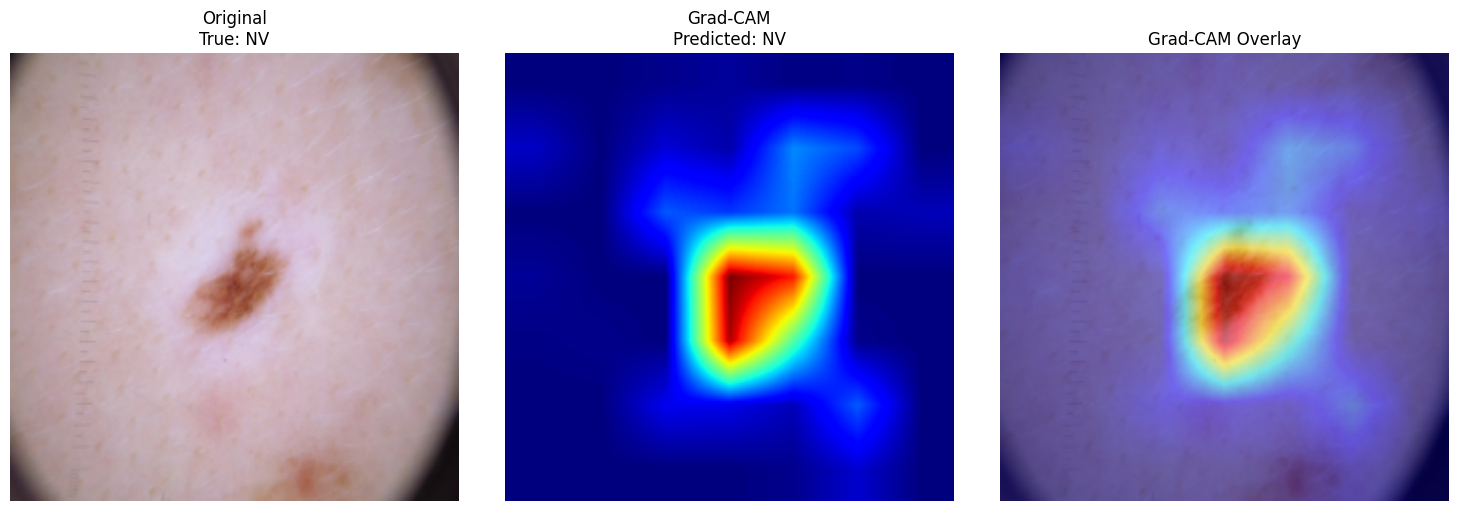

True class: NV
Predicted class: NV
Confidence: 0.5904


In [108]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Original\nTrue: {class_names[true_label]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(grayscale_cam, cmap="jet")
plt.title(f"Grad-CAM\nPredicted: {class_names[predicted_class]}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(visualization)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("True class:", class_names[true_label])
print("Predicted class:", class_names[predicted_class])
print(f"Confidence: {confidence:.4f}")

##GRAD-CAM++

In [109]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [110]:
target_layers = [model.layer4[-1]]

cam_pp = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)

In [111]:
def generate_gradcam_pp(model, dataset, index, cam_pp):
    model.eval()

    image, true_label = dataset[index]

    input_tensor = image.unsqueeze(0).to(device)


    with torch.no_grad():
        output = model(input_tensor)

        probabilities = torch.softmax(output, dim=1)

        predicted_class = output.argmax(dim=1).item()
        confidence = probabilities[0, predicted_class].item()


    targets = [
        ClassifierOutputTarget(predicted_class)
    ]


    rgb_img = image.permute(1, 2, 0).cpu().numpy()

    rgb_img = (rgb_img - rgb_img.min()) / (
        rgb_img.max() - rgb_img.min() + 1e-8
    )


    grayscale_cam = cam_pp(
        input_tensor=input_tensor,
        targets=targets
    )[0]


    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    return (
        image,
        true_label,
        predicted_class,
        confidence,
        grayscale_cam,
        visualization
    )

In [112]:
result_pp = generate_gradcam_pp(
    model,
    val_dataset,
    index=0,
    cam_pp=cam_pp
)

In [113]:
image_pp, true_label_pp, predicted_class_pp, \
confidence_pp, grayscale_cam_pp, visualization_pp = result_pp

In [114]:
print("True class:", class_names[true_label_pp])
print("Predicted class:", class_names[predicted_class_pp])
print(f"Confidence: {confidence_pp:.4f}")

True class: NV
Predicted class: NV
Confidence: 0.5904


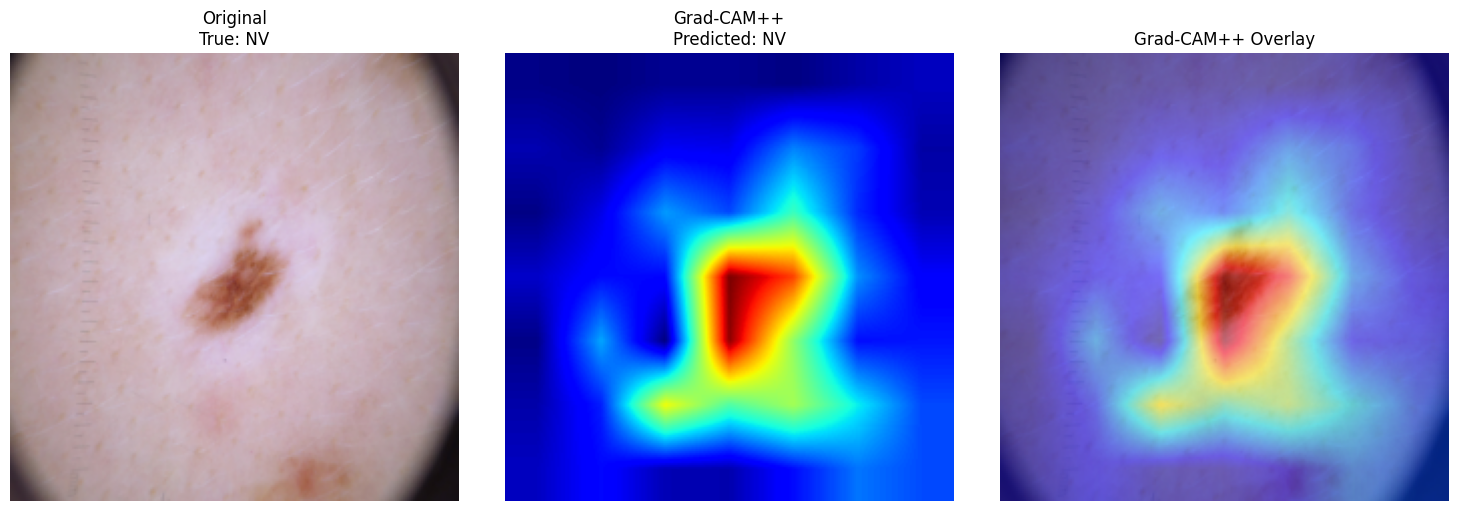

In [115]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_pp.permute(1, 2, 0))
plt.title(
    f"Original\n"
    f"True: {class_names[true_label_pp]}"
)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(grayscale_cam_pp, cmap="jet")
plt.title(
    f"Grad-CAM++\n"
    f"Predicted: {class_names[predicted_class_pp]}"
)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(visualization_pp)
plt.title("Grad-CAM++ Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()